In [1]:
!pip install mlflow dagshub neuralforecast kaggle -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 1.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 82.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 95.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 61.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.1/273.1 kB 24.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.0/294.0 kB 21.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.2/348.2 kB 30.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 98.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.2/68.2 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.

In [2]:
import os
import dagshub
import mlflow

# თუ წინა მუშაობიდან რომელიმე რანი ღია დარჩა, ვხურავთ
mlflow.end_run()

# ინიციალიზაცია კოლაბორაციულ რეპოზე
dagshub.init(
    repo_owner='tsarc21',
    repo_name='Walmart-Recruiting---Store-Sales-Forecasting',
    mlflow=True
)
print("DagsHub & MLflow წარმატებით დაუკავშირდა tsarc21-ის რეპოზიტორიას!")

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

Output()



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=1aba8b72-f8f9-4db9-9376-3be7b5a69c8c&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=c516052c152ab04a6430fb0b61330cece5ae696cf57e7cd4b60c6f9d64d0b72d




Accessing as lkhar21

Initialized MLflow to track repo "tsarc21/Walmart-Recruiting---Store-Sales-Forecasting"

Repository tsarc21/Walmart-Recruiting---Store-Sales-Forecasting initialized!

DagsHub & MLflow წარმატებით დაუკავშირდა tsarc21-ის რეპოზიტორიას!


In [3]:
import os

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle competitions download -c walmart-recruiting-store-sales-forecasting
!unzip -o walmart-recruiting-store-sales-forecasting.zip
!unzip -o train.csv.zip

100% 2.70M/2.70M [00:00<00:00, 193MB/s]

Archive:  walmart-recruiting-store-sales-forecasting.zip
  inflating: features.csv.zip        
  inflating: sampleSubmission.csv.zip  
  inflating: stores.csv              
  inflating: test.csv.zip            
  inflating: train.csv.zip           
Archive:  train.csv.zip
  inflating: train.csv               


In [4]:
import numpy as np
import pandas as pd
import mlflow
from neuralforecast import NeuralForecast
from neuralforecast.models import NBEATS
from neuralforecast.losses.pytorch import MAPE


print("ვამზადებთ მონაცემებს ტრენინგისთვის...")
train_df = pd.read_csv('train.csv')
train_df['unique_id'] = train_df['Store'].astype(str) + '_' + train_df['Dept'].astype(str)
train_df = train_df.rename(columns={'Date': 'ds', 'Weekly_Sales': 'y'})
train_df['ds'] = pd.to_datetime(train_df['ds'])

series_sizes = train_df.groupby('unique_id').size()
valid_series = series_sizes[series_sizes >= 52].index
train_filtered = train_df[train_df['unique_id'].isin(valid_series)].reset_index(drop=True)
print(f"მონაცემები ჩაიტვირთა! სერიების რაოდენობა: {len(valid_series)}")

input_size = 52
h = 39

models_nbeats = [NBEATS(
    h=h,
    input_size=input_size,
    loss=MAPE(),
    max_steps=1500,
    early_stop_patience_steps=10,
    start_padding_enabled=True
)]

nf_nbeats = NeuralForecast(models=models_nbeats, freq='W-FRI')


with mlflow.start_run(run_name="NBEATS_Model_Experiment"):
    mlflow.log_param("model_type", "NBEATS")
    mlflow.log_param("input_size", input_size)
    mlflow.log_param("loss_function", "MAPE")

    print("N-BEATS მოდელის ტრენინგი დაიწყო (შეიძლება რამდენიმე წუთი დასჭირდეს)...")
    nf_nbeats.fit(df=train_filtered, val_size=39)
    print("ტრენინგი წარმატებით დასრულდა!")

    print("იწყება კროს-ვალიდაცია პროგნოზების შესაფასებლად...")
    cv_nbeats_df = nf_nbeats.cross_validation(df=train_filtered, val_size=39, n_windows=1)
    cv_nbeats_df = cv_nbeats_df.reset_index()

    # 3. ვალმარტის ოფიციალური WMAE მეტრიკის კალკულაცია
    original_train_sub = train_df[['unique_id', 'ds', 'IsHoliday']].drop_duplicates()
    cv_eval_nbeats = pd.merge(cv_nbeats_df, original_train_sub, on=['unique_id', 'ds'], how='left')
    cv_eval_nbeats['Weight'] = np.where(cv_eval_nbeats['IsHoliday'] == True, 5, 1)

    absolute_errors_nbeats = np.abs(cv_eval_nbeats['y'] - cv_eval_nbeats['NBEATS'])
    wmae_nbeats = np.sum(cv_eval_nbeats['Weight'] * absolute_errors_nbeats) / np.sum(cv_eval_nbeats['Weight'])

    print("\n==================================================")
    print(f"N-BEATS მოდელის საბოლოო WMAE: ${wmae_nbeats:.2f}")
    print("==================================================")

    mlflow.log_metric("nbeats_wmae", wmae_nbeats)

    # 4. მოდელის შენახვა
    nf_nbeats.save(path='./nbeats_pipeline', overwrite=True)
    mlflow.log_artifacts('./nbeats_pipeline', artifact_path="model_pipeline")
    print("მოდელის ფაილები და მეტრიკები წარმატებით აიტვირთა DagsHub-ზე!")

ვამზადებთ მონაცემებს ტრენინგისთვის...


INFO:lightning_fabric.utilities.seed:Seed set to 1


მონაცემები ჩაიტვირთა! სერიების რაოდენობა: 2991
N-BEATS მოდელის ტრენინგი დაიწყო (შეიძლება რამდენიმე წუთი დასჭირდეს)...


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name         | Type          | Params | Mode 
-------------------------------------------------------
0 | loss         | MAPE          | 0      | train
1 | padder_train | ConstantPad1d | 0      | train
2 | scaler       | TemporalNorm  | 0      | train
3 | blocks       | ModuleList    | 2.6 M  | train
-------------------------------------------------------
2.6 M     Trainable params
7.2 K     Non-trainable params
2.6 M     Total params
10.321    Total estimated model params size (MB)
31        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=1500` reached.
INFO:pytorch_lightning.utilities.rank_zero:Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.model_summary.ModelSummary'>]. Skipping setting a default `ModelSummary` callback.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]


N-BEATS მოდელის საბოლოო WMAE: $3068.01
მოდელის ფაილები და მეტრიკები წარმატებით აიტვირთა DagsHub-ზე!
🏃 View run NBEATS_Model_Experiment at: https://dagshub.com/tsarc21/Walmart-Recruiting---Store-Sales-Forecasting.mlflow/#/experiments/0/runs/bfba52bbc1d74eebaf17a28c3759cdd8
🧪 View experiment at: https://dagshub.com/tsarc21/Walmart-Recruiting---Store-Sales-Forecasting.mlflow/#/experiments/0


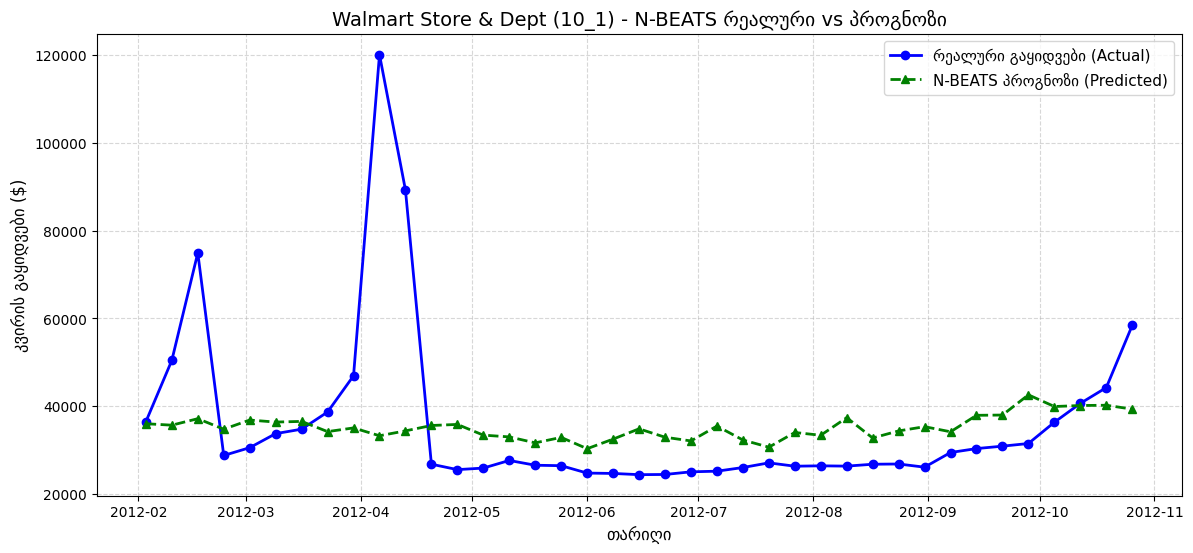

📈 N-BEATS შედარების გრაფიკი წარმატებით აიტვირთა MLflow-ზე!
🏃 View run NBEATS_Model_Experiment at: https://dagshub.com/tsarc21/Walmart-Recruiting---Store-Sales-Forecasting.mlflow/#/experiments/0/runs/bfba52bbc1d74eebaf17a28c3759cdd8
🧪 View experiment at: https://dagshub.com/tsarc21/Walmart-Recruiting---Store-Sales-Forecasting.mlflow/#/experiments/0


In [5]:
import matplotlib.pyplot as plt

# 1. ავიღოთ საჩვენებლად პირველივე ხელმისაწვდომი უნიკალური ID
sample_id = cv_nbeats_df['unique_id'].iloc[0]
sample_df = cv_nbeats_df[cv_nbeats_df['unique_id'] == sample_id].sort_values('ds')

# 2. გრაფიკის აგება
plt.figure(figsize=(14, 6))
plt.plot(sample_df['ds'], sample_df['y'], label='რეალური გაყიდვები (Actual)', color='blue', marker='o', linewidth=2)
plt.plot(sample_df['ds'], sample_df['NBEATS'], label='N-BEATS პროგნოზი (Predicted)', color='green', linestyle='--', marker='^', linewidth=2)

plt.title(f'Walmart Store & Dept ({sample_id}) - N-BEATS რეალური vs პროგნოზი', fontsize=14)
plt.xlabel('თარიღი', fontsize=12)
plt.ylabel('კვირის გაყიდვები ($)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)

# 3. გრაფიკის შენახვა და MLflow-ში გაგზავნა
nbeats_plot_path = 'nbeats_actual_vs_pred.png'
plt.savefig(nbeats_plot_path, bbox_inches='tight')
plt.show()

active_run = mlflow.last_active_run()
if active_run is not None:
    with mlflow.start_run(run_id=active_run.info.run_id):
        mlflow.log_artifact(nbeats_plot_path, artifact_path="plots")
        print("📈 N-BEATS შედარების გრაფიკი წარმატებით აიტვირთა MLflow-ზე!")

N-BEATS მოდელის დასწავლის რიცხვითი პარამეტრები:
R² Score: 0.9239 (92.39%-ს ხსნის მოდელი)
საერთო MAE: $2945.66
 დღესასწაულების კვირის MAE: $3648.89
ჩვეულებრივი კვირის MAE: $2906.58


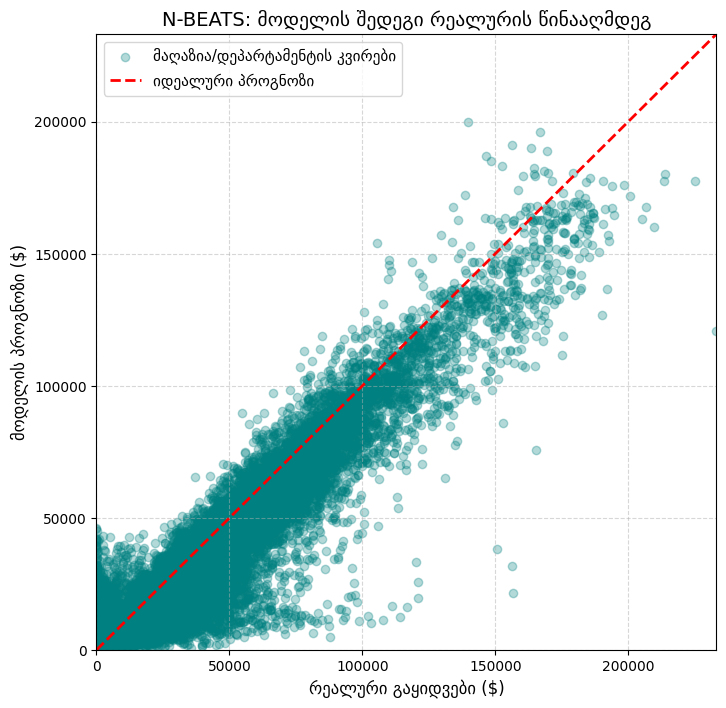

 N-BEATS-ის ყველა მეტრიკა და სკატერ პლოტი წარმატებით აიტვირთა DagsHub-ზე!
🏃 View run NBEATS_Model_Experiment at: https://dagshub.com/tsarc21/Walmart-Recruiting---Store-Sales-Forecasting.mlflow/#/experiments/0/runs/bfba52bbc1d74eebaf17a28c3759cdd8
🧪 View experiment at: https://dagshub.com/tsarc21/Walmart-Recruiting---Store-Sales-Forecasting.mlflow/#/experiments/0


In [6]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error

actuals_nb = cv_eval_nbeats['y'].values
predictions_nb = cv_eval_nbeats['NBEATS'].values

r2_nb = r2_score(actuals_nb, predictions_nb)
mae_nb = mean_absolute_error(actuals_nb, predictions_nb)

holiday_mask_nb = cv_eval_nbeats['IsHoliday'] == True
mae_hol_nb = mean_absolute_error(actuals_nb[holiday_mask_nb], predictions_nb[holiday_mask_nb])
mae_reg_nb = mean_absolute_error(actuals_nb[~holiday_mask_nb], predictions_nb[~holiday_mask_nb])

print("==================================================")
print("N-BEATS მოდელის დასწავლის რიცხვითი პარამეტრები:")
print("==================================================")
print(f"R² Score: {r2_nb:.4f} ({r2_nb*100:.2f}%-ს ხსნის მოდელი)")
print(f"საერთო MAE: ${mae_nb:.2f}")
print(f" დღესასწაულების კვირის MAE: ${mae_hol_nb:.2f}")
print(f"ჩვეულებრივი კვირის MAE: ${mae_reg_nb:.2f}")
print("==================================================")

# Scatter Plot-ის აგება
plt.figure(figsize=(8, 8))
plt.scatter(actuals_nb, predictions_nb, alpha=0.3, color='teal', label='მაღაზია/დეპარტამენტის კვირები')

max_val_nb = max(max(actuals_nb), max(predictions_nb))
plt.plot([0, max_val_nb], [0, max_val_nb], color='red', linestyle='--', linewidth=2, label='იდეალური პროგნოზი')

plt.title('N-BEATS: მოდელის შედეგი რეალურის წინააღმდეგ', fontsize=14)
plt.xlabel('რეალური გაყიდვები ($)', fontsize=12)
plt.ylabel('მოდელის პროგნოზი ($)', fontsize=12)
plt.xlim(0, max_val_nb)
plt.ylim(0, max_val_nb)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=11)

nbeats_scatter_path = 'nbeats_metrics_scatter.png'
plt.savefig(nbeats_scatter_path, bbox_inches='tight')
plt.show()

# ლოგირება MLflow-ში
if active_run is not None:
    with mlflow.start_run(run_id=active_run.info.run_id):
        mlflow.log_metric("r2_score_nbeats", r2_nb)
        mlflow.log_metric("mae_holidays_nbeats", mae_hol_nb)
        mlflow.log_metric("mae_regular_nbeats", mae_reg_nb)
        mlflow.log_artifact(nbeats_scatter_path, artifact_path="plots")
        print(" N-BEATS-ის ყველა მეტრიკა და სკატერ პლოტი წარმატებით აიტვირთა DagsHub-ზე!")

In [7]:
import numpy as np
import pandas as pd
import mlflow
from neuralforecast import NeuralForecast
from neuralforecast.models import NBEATS
from neuralforecast.losses.pytorch import MAE  # შევცვალეთ MAE-ზე

input_size = 52
h = 39

# N-BEATS-ის გაძლიერებული და ინტერპრეტირებადი არქიტექტურა
models_nbeats_tuned = [NBEATS(
    h=h,
    input_size=input_size,
    loss=MAE(),
    stack_types=['trend', 'seasonality'],
    n_blocks=[3, 3],
    mlp_units=[[512, 512], [512, 512]],
    max_steps=1500,
    early_stop_patience_steps=10,
    start_padding_enabled=True
)]

nf_nbeats_tuned = NeuralForecast(models=models_nbeats_tuned, freq='W-FRI')

# ახალი ლოგირება განსხვავებული სახელით
with mlflow.start_run(run_name="NBEATS_Tuned_Experiment"):
    mlflow.log_param("model_type", "NBEATS_Tuned")
    mlflow.log_param("stack_types", "trend_seasonality")
    mlflow.log_param("loss_function", "MAE")

    print(" იწყება N-BEATS-ის გაძლიერებული ვერსიის ტრენინგი...")
    nf_nbeats_tuned.fit(df=train_filtered, val_size=39)
    print(" გაძლიერებული მოდელის ტრენინგი დასრულდა!")

    print(" კროს-ვალიდაცია გაძლიერებული მოდელისთვის...")
    cv_nbeats_tuned_df = nf_nbeats_tuned.cross_validation(df=train_filtered, val_size=39, n_windows=1)
    cv_nbeats_tuned_df = cv_nbeats_tuned_df.reset_index()

    # ვალმარტის WMAE კალკულაცია
    original_train_sub = train_df[['unique_id', 'ds', 'IsHoliday']].drop_duplicates()
    cv_eval_nbeats_tuned = pd.merge(cv_nbeats_tuned_df, original_train_sub, on=['unique_id', 'ds'], how='left')
    cv_eval_nbeats_tuned['Weight'] = np.where(cv_eval_nbeats_tuned['IsHoliday'] == True, 5, 1)

    absolute_errors_tuned = np.abs(cv_eval_nbeats_tuned['y'] - cv_eval_nbeats_tuned['NBEATS'])
    wmae_nbeats_tuned = np.sum(cv_eval_nbeats_tuned['Weight'] * absolute_errors_tuned) / np.sum(cv_eval_nbeats_tuned['Weight'])

    print("\n==================================================")
    print(f"🚀 TUNED N-BEATS მოდელის საბოლოო WMAE: ${wmae_nbeats_tuned:.2f}")
    print("==================================================")

    mlflow.log_metric("nbeats_tuned_wmae", wmae_nbeats_tuned)

    # პაიპლაინის შენახვა
    nf_nbeats_tuned.save(path='./nbeats_tuned_pipeline', overwrite=True)
    mlflow.log_artifacts('./nbeats_tuned_pipeline', artifact_path="model_tuned_pipeline")
    print(" გაძლიერებული მოდელის მონაცემები წარმატებით აიტვირთა DagsHub-ზე!")

INFO:lightning_fabric.utilities.seed:Seed set to 1


🔥 იწყება N-BEATS-ის გაძლიერებული ვერსიის ტრენინგი...


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name         | Type          | Params | Mode 
-------------------------------------------------------
0 | loss         | MAE           | 0      | train
1 | padder_train | ConstantPad1d | 0      | train
2 | scaler       | TemporalNorm  | 0      | train
3 | blocks       | ModuleList    | 3.6 M  | train
-------------------------------------------------------
3.6 M     Trainable params
21.6 K    Non-trainable params
3.6 M     Total params
14.318    Total estimated model params size (MB)
52        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.model_summary.ModelSummary'>]. Skipping setting a default `ModelSummary` callback.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]


🚀 TUNED N-BEATS მოდელის საბოლოო WMAE: $2080.87
📦 გაძლიერებული მოდელის მონაცემები წარმატებით აიტვირთა DagsHub-ზე!
🏃 View run NBEATS_Tuned_Experiment at: https://dagshub.com/tsarc21/Walmart-Recruiting---Store-Sales-Forecasting.mlflow/#/experiments/0/runs/2d20a0618d0945e89f9bcad762f74a02
🧪 View experiment at: https://dagshub.com/tsarc21/Walmart-Recruiting---Store-Sales-Forecasting.mlflow/#/experiments/0


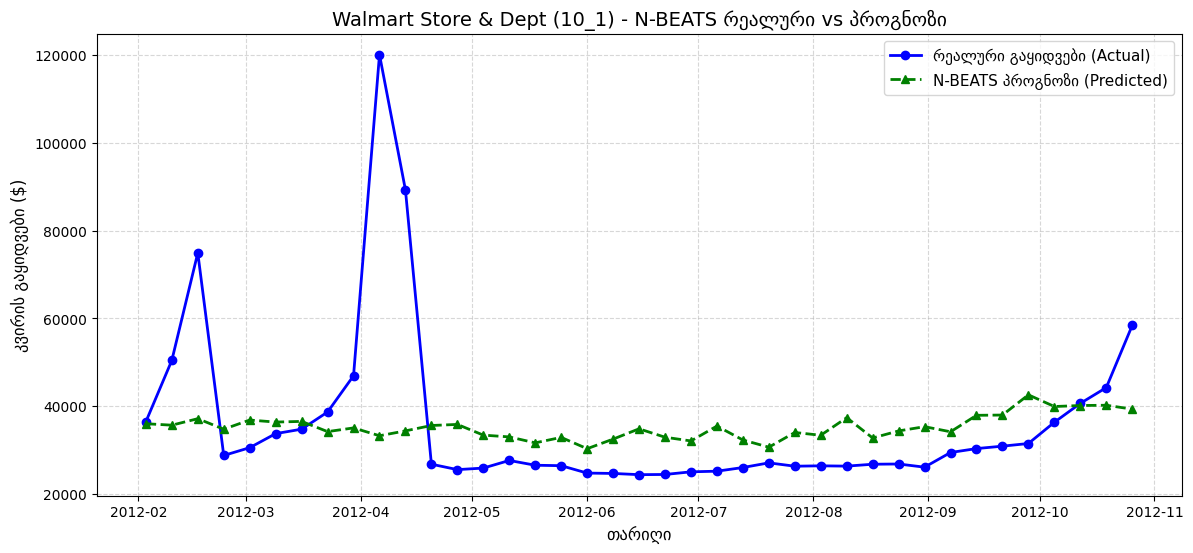

📈 N-BEATS შედარების გრაფიკი წარმატებით აიტვირთა MLflow-ზე!
🏃 View run NBEATS_Tuned_Experiment at: https://dagshub.com/tsarc21/Walmart-Recruiting---Store-Sales-Forecasting.mlflow/#/experiments/0/runs/2d20a0618d0945e89f9bcad762f74a02
🧪 View experiment at: https://dagshub.com/tsarc21/Walmart-Recruiting---Store-Sales-Forecasting.mlflow/#/experiments/0


In [8]:
import matplotlib.pyplot as plt
import mlflow

sample_id = cv_nbeats_df['unique_id'].iloc[0]
sample_df = cv_nbeats_df[cv_nbeats_df['unique_id'] == sample_id].sort_values('ds')

plt.figure(figsize=(14, 6))
plt.plot(sample_df['ds'], sample_df['y'], label='რეალური გაყიდვები (Actual)', color='blue', marker='o', linewidth=2)
plt.plot(sample_df['ds'], sample_df['NBEATS'], label='N-BEATS პროგნოზი (Predicted)', color='green', linestyle='--', marker='^', linewidth=2)

plt.title(f'Walmart Store & Dept ({sample_id}) - N-BEATS რეალური vs პროგნოზი', fontsize=14)
plt.xlabel('თარიღი', fontsize=12)
plt.ylabel('კვირის გაყიდვები ($)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)

nbeats_plot_path = 'nbeats_actual_vs_pred.png'
plt.savefig(nbeats_plot_path, bbox_inches='tight')
plt.show()

active_run = mlflow.last_active_run()
if active_run is not None:
    with mlflow.start_run(run_id=active_run.info.run_id):
        mlflow.log_artifact(nbeats_plot_path, artifact_path="plots")
        print("📈 N-BEATS შედარების გრაფიკი წარმატებით აიტვირთა MLflow-ზე!")

N-BEATS მოდელის დასწავლის რიცხვითი პარამეტრები:
R² Score: 0.9239 (92.39%-ს ხსნის მოდელი)
საერთო MAE: $2945.66
დღესასწაულების კვირის MAE: $3648.89
ჩვეულებრივი კვირის MAE: $2906.58


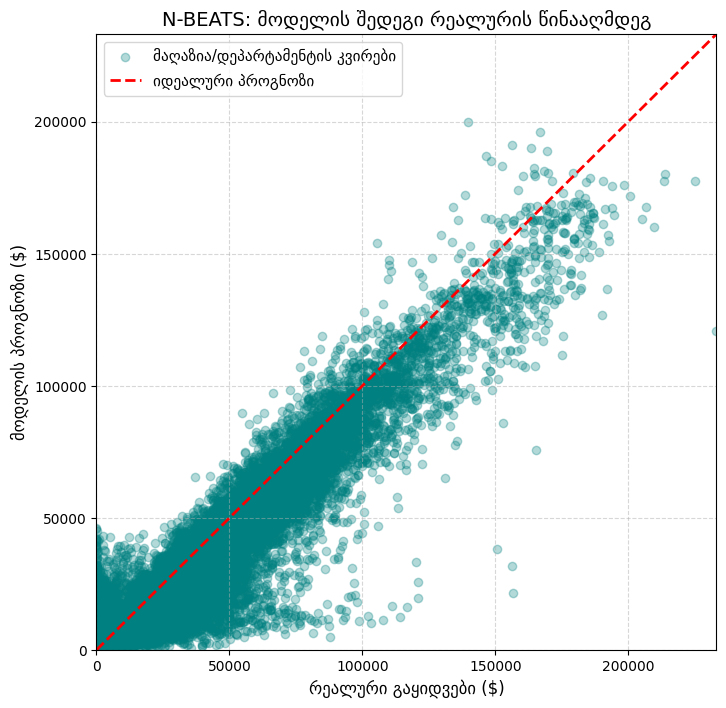

N-BEATS-ის ყველა მეტრიკა და სკატერ პლოტი წარმატებით აიტვირთა DagsHub-ზე!
🏃 View run NBEATS_Tuned_Experiment at: https://dagshub.com/tsarc21/Walmart-Recruiting---Store-Sales-Forecasting.mlflow/#/experiments/0/runs/2d20a0618d0945e89f9bcad762f74a02
🧪 View experiment at: https://dagshub.com/tsarc21/Walmart-Recruiting---Store-Sales-Forecasting.mlflow/#/experiments/0


In [9]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error

actuals_nb = cv_eval_nbeats['y'].values
predictions_nb = cv_eval_nbeats['NBEATS'].values

r2_nb = r2_score(actuals_nb, predictions_nb)
mae_nb = mean_absolute_error(actuals_nb, predictions_nb)

holiday_mask_nb = cv_eval_nbeats['IsHoliday'] == True
mae_hol_nb = mean_absolute_error(actuals_nb[holiday_mask_nb], predictions_nb[holiday_mask_nb])
mae_regular_nb = mean_absolute_error(actuals_nb[~holiday_mask_nb], predictions_nb[~holiday_mask_nb])

print("==================================================")
print("N-BEATS მოდელის დასწავლის რიცხვითი პარამეტრები:")
print("==================================================")
print(f"R² Score: {r2_nb:.4f} ({r2_nb*100:.2f}%-ს ხსნის მოდელი)")
print(f"საერთო MAE: ${mae_nb:.2f}")
print(f"დღესასწაულების კვირის MAE: ${mae_hol_nb:.2f}")
print(f"ჩვეულებრივი კვირის MAE: ${mae_regular_nb:.2f}")
print("==================================================")

# Scatter Plot-ის აგება
plt.figure(figsize=(8, 8))
plt.scatter(actuals_nb, predictions_nb, alpha=0.3, color='teal', label='მაღაზია/დეპარტამენტის კვირები')

max_val_nb = max(max(actuals_nb), max(predictions_nb))
plt.plot([0, max_val_nb], [0, max_val_nb], color='red', linestyle='--', linewidth=2, label='იდეალური პროგნოზი')

plt.title('N-BEATS: მოდელის შედეგი რეალურის წინააღმდეგ', fontsize=14)
plt.xlabel('რეალური გაყიდვები ($)', fontsize=12)
plt.ylabel('მოდელის პროგნოზი ($)', fontsize=12)
plt.xlim(0, max_val_nb)
plt.ylim(0, max_val_nb)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=11)

nbeats_scatter_path = 'nbeats_metrics_scatter.png'
plt.savefig(nbeats_scatter_path, bbox_inches='tight')
plt.show()

# ლოგირება MLflow-ში
if active_run is not None:
    with mlflow.start_run(run_id=active_run.info.run_id):
        mlflow.log_metric("r2_score_nbeats", r2_nb)
        mlflow.log_metric("mae_holidays_nbeats", mae_hol_nb)
        mlflow.log_metric("mae_regular_nbeats", mae_regular_nb)
        mlflow.log_artifact(nbeats_scatter_path, artifact_path="plots")
        print("N-BEATS-ის ყველა მეტრიკა და სკატერ პლოტი წარმატებით აიტვირთა DagsHub-ზე!")

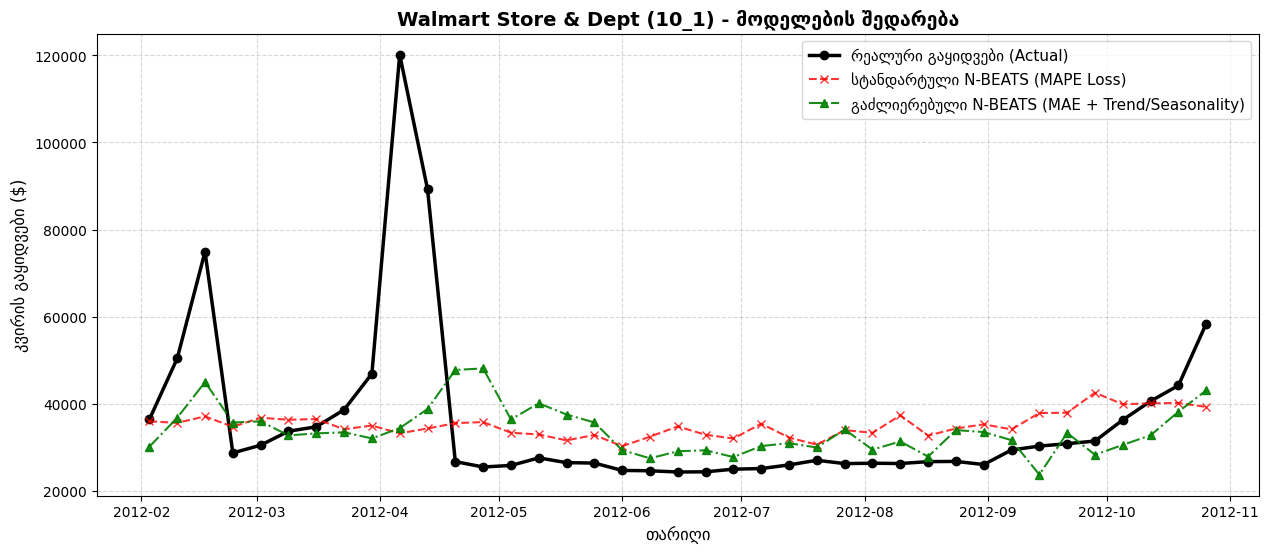

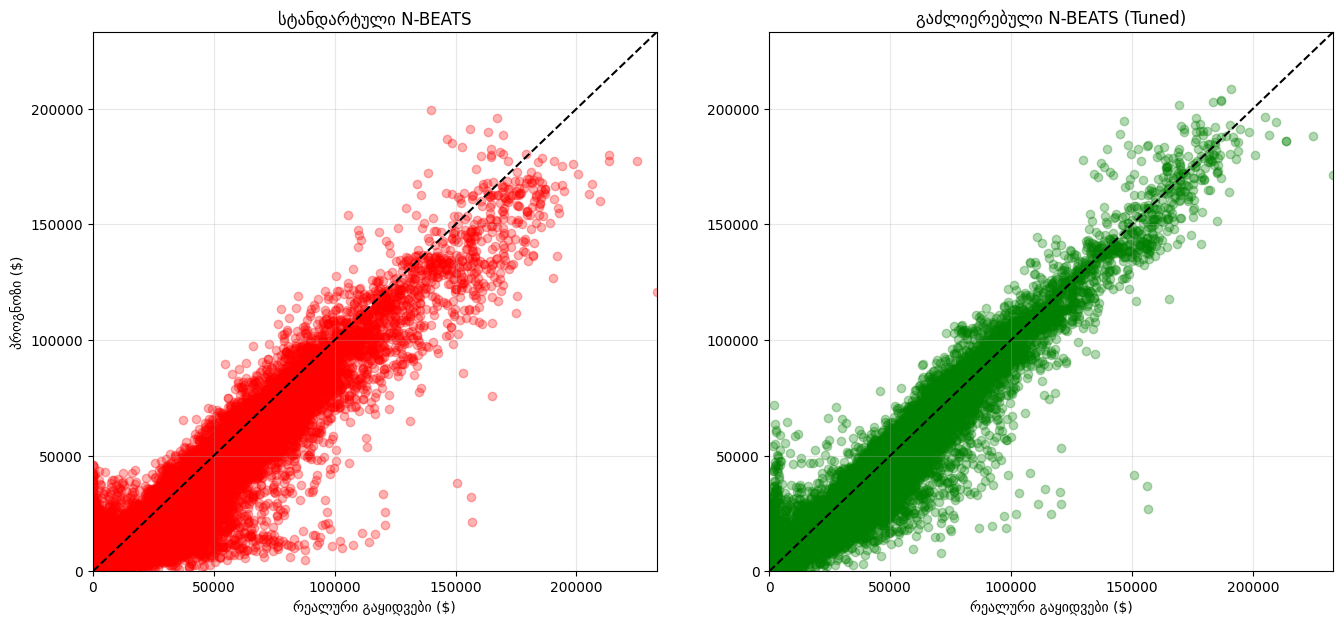

📊 ორივე შედარებითი გრაფიკი წარმატებით აიტვირთა MLflow/DagsHub-ზე!
🏃 View run NBEATS_Tuned_Experiment at: https://dagshub.com/tsarc21/Walmart-Recruiting---Store-Sales-Forecasting.mlflow/#/experiments/0/runs/2d20a0618d0945e89f9bcad762f74a02
🧪 View experiment at: https://dagshub.com/tsarc21/Walmart-Recruiting---Store-Sales-Forecasting.mlflow/#/experiments/0


In [10]:
import matplotlib.pyplot as plt
import numpy as np
import mlflow

# 1. მონაცემების მომზადება საჩვენებელი სერიისთვის
sample_id = cv_nbeats_df['unique_id'].iloc[0]
df_base = cv_nbeats_df[cv_nbeats_df['unique_id'] == sample_id].sort_values('ds')
df_tuned = cv_nbeats_tuned_df[cv_nbeats_tuned_df['unique_id'] == sample_id].sort_values('ds')

# ==========================================
# გრაფიკი 1: რეალური გაყიდვები VS ორივე მოდელი
# ==========================================
plt.figure(figsize=(15, 6))
plt.plot(df_base['ds'], df_base['y'], label='რეალური გაყიდვები (Actual)', color='black', marker='o', linewidth=2.5)
plt.plot(df_base['ds'], df_base['NBEATS'], label='სტანდარტული N-BEATS (MAPE Loss)', color='red', linestyle='--', marker='x', alpha=0.8)
plt.plot(df_tuned['ds'], df_tuned['NBEATS'], label='გაძლიერებული N-BEATS (MAE + Trend/Seasonality)', color='green', linestyle='-.', marker='^', alpha=0.9)

plt.title(f'Walmart Store & Dept ({sample_id}) - მოდელების შედარება', fontsize=14, fontweight='bold')
plt.xlabel('თარიღი', fontsize=12)
plt.ylabel('კვირის გაყიდვები ($)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)

comparison_plot_path = 'nbeats_models_comparison.png'
plt.savefig(comparison_plot_path, bbox_inches='tight')
plt.show()

# ==========================================
# გრაფიკი 2: Scatter Plots გვერდიგვერდ
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
max_val = max(cv_eval_nbeats['y'].max(), cv_eval_nbeats['NBEATS'].max(), cv_eval_nbeats_tuned['NBEATS'].max())

# მარცხენა: სტანდარტული მოდელი
ax1.scatter(cv_eval_nbeats['y'], cv_eval_nbeats['NBEATS'], alpha=0.3, color='red')
ax1.plot([0, max_val], [0, max_val], color='black', linestyle='--')
ax1.set_title('სტანდარტული N-BEATS', fontsize=12)
ax1.set_xlabel('რეალური გაყიდვები ($)')
ax1.set_ylabel('პროგნოზი ($)')
ax1.set_xlim(0, max_val)
ax1.set_ylim(0, max_val)
ax1.grid(True, alpha=0.3)

# მარჯვენა: გაძლიერებული მოდელი
ax2.scatter(cv_eval_nbeats_tuned['y'], cv_eval_nbeats_tuned['NBEATS'], alpha=0.3, color='green')
ax2.plot([0, max_val], [0, max_val], color='black', linestyle='--')
ax2.set_title('გაძლიერებული N-BEATS (Tuned)', fontsize=12)
ax2.set_xlabel('რეალური გაყიდვები ($)')
ax2.set_xlim(0, max_val)
ax2.set_ylim(0, max_val)
ax2.grid(True, alpha=0.3)

scatter_plot_path = 'nbeats_scatter_comparison.png'
plt.savefig(scatter_plot_path, bbox_inches='tight')
plt.show()

# ==========================================
# 3. ორივე გრაფიკის ატვირთვა ბოლო აქტიურ რანში
# ==========================================
active_run = mlflow.last_active_run()
if active_run is not None:
    with mlflow.start_run(run_id=active_run.info.run_id):
        mlflow.log_artifact(comparison_plot_path, artifact_path="plots")
        mlflow.log_artifact(scatter_plot_path, artifact_path="plots")
        print("📊 ორივე შედარებითი გრაფიკი წარმატებით აიტვირთა MLflow/DagsHub-ზე!")